# Milestone 2 — Data Analysis & Visualization
**Project:** Walmart Sales Forecasting

In Milestone 1 I found that Store and seasonality (month/holidays) are the strongest drivers of sales, while economic indicators (CPI, Unemployment, Fuel Price, Temperature) are weakly correlated. In this notebook I dig a bit deeper into the seasonal pattern and build an interactive dashboard to explore the data by store.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

df = pd.read_csv('../data/processed/walmart_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Week,Day_of_Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010,5,4
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010,6,4
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010,7,4
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010,8,4
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010,9,4


## 1. Seasonal decomposition of total sales

In Milestone 1 the trend chart showed yearly spikes. Let's decompose the series into trend, seasonal and residual components to confirm this formally.

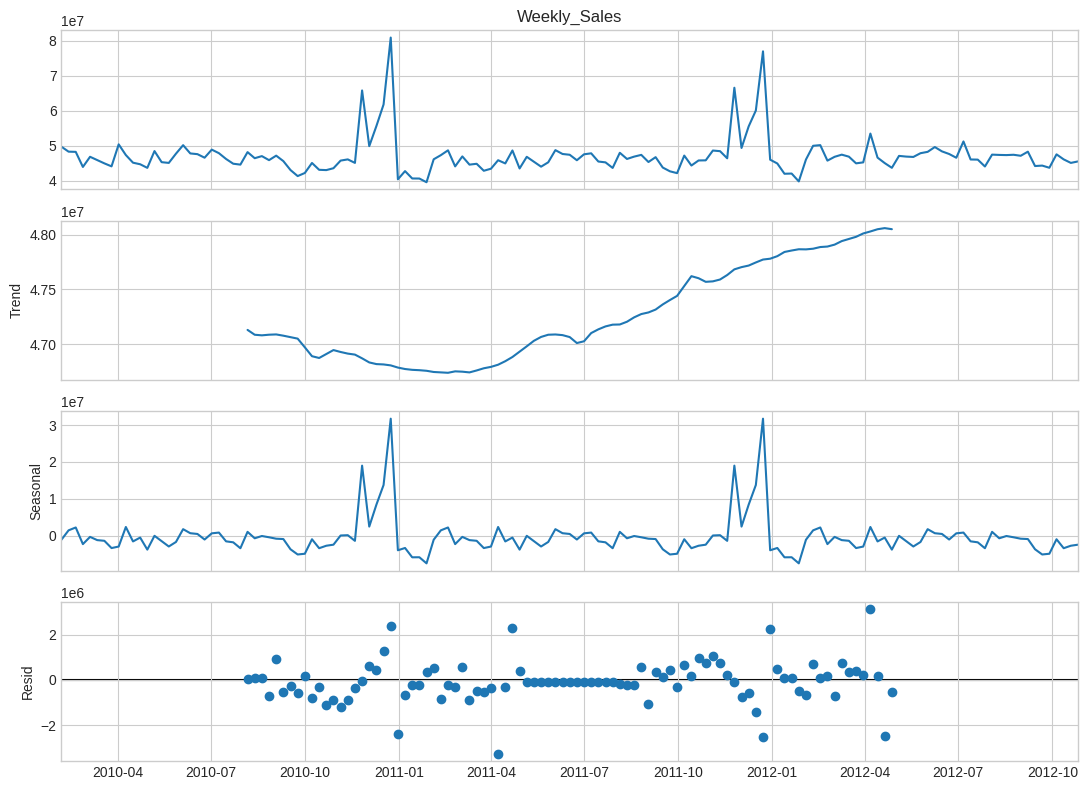

In [2]:
total_weekly = df.groupby('Date')['Weekly_Sales'].sum().asfreq('W-FRI')

decomposition = seasonal_decompose(total_weekly, model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.savefig('../reports/figures/07_seasonal_decompose.png', dpi=110)
plt.show()

The decomposition confirms what I saw earlier:
- **Trend**: roughly flat / slightly declining across the ~2.7 years (the small dip at the end is partly because 2012 data stops in October, so it's not a full year).
- **Seasonal**: a strong, repeating yearly pattern with a clear peak — matches the December holiday spike.
- **Residual**: noise left after removing trend and seasonality, with a couple of sharp spikes (most likely Thanksgiving/Black Friday weeks, which don't perfectly repeat at the same week number every year).

## 2. Year-over-year comparison

A quick note before comparing years: 2012 only has data up to October, so it's not a full year. I'll keep that in mind when comparing yearly totals.

In [3]:
yearly_avg = df.groupby('Year')['Weekly_Sales'].agg(['mean', 'count'])
yearly_avg

,mean,count
Year,,
2010,1.059670e+06,2160
2011,1.046239e+06,2340
2012,1.033660e+06,1935


Average weekly sales look fairly stable year over year (~\$1.03M-\$1.06M), no strong long-term growth or decline. The small drop in 2012 is likely just because that year is missing Nov/Dec, which are the strongest months.

## 3. Interactive dashboard — sales by store

This is an interactive Plotly chart: pick a store from the dropdown to see its weekly sales trend, or compare it against the overall average.

In [4]:
store_weekly = df.groupby(['Store', 'Date'])['Weekly_Sales'].sum().reset_index()

fig = px.line(
    store_weekly,
    x='Date', y='Weekly_Sales', color='Store',
    title='Weekly Sales per Store (use legend to isolate one store)',
    labels={'Weekly_Sales': 'Weekly Sales ($)'}
)
fig.update_layout(legend_title_text='Store', height=550)
fig.show()

## 4. Holiday weeks highlighted on the total sales trend

In [5]:
total_weekly_df = df.groupby('Date').agg(
    Weekly_Sales=('Weekly_Sales', 'sum'),
    Holiday_Flag=('Holiday_Flag', 'max')
).reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=total_weekly_df['Date'], y=total_weekly_df['Weekly_Sales'],
    mode='lines', name='Total Weekly Sales', line=dict(color='#1f77b4')
))

holidays = total_weekly_df[total_weekly_df['Holiday_Flag'] == 1]
fig.add_trace(go.Scatter(
    x=holidays['Date'], y=holidays['Weekly_Sales'],
    mode='markers', name='Holiday Week', marker=dict(color='red', size=9)
))

fig.update_layout(title='Total Weekly Sales with Holiday Weeks Highlighted', height=500,
                   xaxis_title='Date', yaxis_title='Total Weekly Sales ($)')
fig.show()

Interesting — most red (holiday) markers don't actually land exactly on the year-end peaks. The big spikes happen the week *right after* Thanksgiving (Black Friday shopping), while the `Holiday_Flag` in this dataset marks the holiday week itself. This is a useful detail for modeling: a simple holiday flag may not fully capture the pre/post-holiday shopping surge, so lag features around holidays could help later.

## 5. Store performance comparison (top vs bottom)

In [6]:
top_store = 20
bottom_store = 33

compare_df = store_weekly[store_weekly['Store'].isin([top_store, bottom_store])]

fig = px.line(
    compare_df, x='Date', y='Weekly_Sales', color='Store',
    title=f'Store {top_store} (highest avg sales) vs Store {bottom_store} (lowest avg sales)',
    labels={'Weekly_Sales': 'Weekly Sales ($)'}
)
fig.update_layout(height=450)
fig.show()

Both stores follow the **same seasonal shape** (peaks at the same time of year), just at very different scales. This is good news for modeling — it suggests a single model with `Store` as a feature can probably capture both the store-level scale and the shared seasonal pattern, instead of needing a fully separate model per store.

## Summary of findings

- Seasonal decomposition confirms a strong **yearly seasonal pattern** with a flat/slightly declining trend (note: 2012 is a partial year, missing Nov/Dec).
- The biggest sales spikes happen mainly **after Thanksgiving**, not exactly on the days flagged as `Holiday_Flag = 1` — worth exploring lag/lead holiday features later.
- Stores differ a lot in scale but follow a **similar seasonal shape**, so a single model with `Store` as a feature looks like a reasonable approach rather than training 45 separate models.

**Next step (Milestone 3):** build and compare forecasting models (baseline, Prophet, XGBoost) using `Store`, time-based features, and holiday information.